# Model audit — Cordilla Systems account scoring

**What this notebook is.** An audit of `model/model.pkl`, a scoring model found unused in
the Salesforce environment. Nobody flagged it, so nobody is vouching for it. The question
is not "how good is it" but **"does it deserve to be trusted, and with what."**

**What it is not.** It does not retrain, tune, or replace the shipped model. Section 0.4
establishes exactly one exception and why it is not retraining.

**Reference date is 2026-08-01**, not the system clock. Both CSVs are static snapshots
taken that day.

---

### Contents

| § | | one-line finding |
|---|---|---|
| **0** | Integrity and provenance | The pickle was fit on all 1200 labeled rows, in file order, with no holdout — proven bit-for-bit |
| **1** | What is in the box | 40 stumps of depth 2; median imputation on the one column that has gaps |
| **2** | Reported vs. real performance | **The headline AUC of 0.759 is what this architecture produces from random labels** |
| **3** | Every variable, one at a time | Importance tracks cardinality, not signal; `intent_score` contributes only its missingness |
| **4** | Stability and robustness | Half the call list is an artifact of the random seed; a null `account_type` crashes scoring |
| **5** | Allocation impact | Rep hours are split 5.6× across industries on the basis of no measured difference |
| **6** | Consolidated verdict | What to trust, what not to, what not to ship |

In [1]:
import warnings, pickle, hashlib, itertools
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 60, "display.float_format", lambda v: f"{v:,.4f}")

TODAY    = pd.Timestamp("2026-08-01")     # the packet's "today", not the system clock
FEATURES = ["account_type", "employee_count", "industry", "intent_score", "mql_count_90d",
            "trial_started", "trial_active_users", "web_touchpoints_90d", "sales_contacts_90d"]
CAT      = ["account_type", "industry"]
NUM      = [f for f in FEATURES if f not in CAT]
TARGET   = "converted_within_90d"

# one house style for every figure in the notebook
mpl.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .6,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 9,
                     "legend.frameon": False})
INK, WARN, GOOD, MUTE = "#1f3a5f", "#c2402a", "#2f7d54", "#9aa5b1"

def show(df, title=None, n=None):
    if title: print(f"\n{title}\n" + "-" * len(title))
    print((df.head(n) if n else df).to_string())

In [2]:
train = pd.read_csv("../data/training_data.csv", parse_dates=["snapshot_date"])
score = pd.read_csv("../data/accounts_to_score.csv", parse_dates=["snapshot_date"])
with open("../model/model.pkl", "rb") as f:
    model = pickle.load(f)

X,  y  = train[FEATURES], train[TARGET].to_numpy()
Xs     = score[FEATURES]
BASE   = y.mean()

for name, df in [("training", train), ("scoring", score)]:
    print(f"{name:9s} {df.shape[0]:5,d} rows x {df.shape[1]:2d} cols   "
          f"snapshots {df.snapshot_date.min():%Y-%m-%d} .. {df.snapshot_date.max():%Y-%m-%d}")
print(f"\npositives {y.sum()} / {len(y)}  =  base rate {BASE:.4%}")
print(f"model.pkl sha256 {hashlib.sha256(open('../model/model.pkl','rb').read()).hexdigest()[:16]}")

training  1,200 rows x 12 cols   snapshots 2024-08-20 .. 2026-07-31
scoring     300 rows x 11 cols   snapshots 2024-09-25 .. 2026-08-01

positives 78 / 1200  =  base rate 6.5000%
model.pkl sha256 fc2cd6aa4400c6bc


## 0. Integrity and provenance

Before any metric, two questions. Are the files internally sound? And — the one nobody
asks — **what exactly was this model fit on?** Everything in §2 depends on the answer.

### 0.1 Integrity checks

Negative results are findings too. Reporting what an audit *did not* find is what stops
the next reader from re-running it.

In [3]:
checks = []
def chk(name, ok, detail=""):
    checks.append({"check": name, "result": "pass" if ok else "FLAG", "detail": detail})

both = pd.concat([train.assign(_src="train"), score.assign(_src="score")], ignore_index=True)

chk("no duplicate account_id within either file",
    train.account_id.is_unique and score.account_id.is_unique)
overlap = set(train.account_id) & set(score.account_id)
chk("no train/score account overlap", not overlap, f"{len(overlap)} shared ids")
chk("no snapshot_date after 2026-08-01", both.snapshot_date.max() <= TODAY,
    f"max {both.snapshot_date.max():%Y-%m-%d}")
chk("employee_count strictly positive", (both.employee_count > 0).all(),
    f"range {both.employee_count.min()}-{both.employee_count.max():,}")
chk("trial_active_users never exceeds employee_count",
    (both.trial_active_users <= both.employee_count).all())
chk("trial_active_users == 0 whenever trial_started == 0",
    (both.loc[both.trial_started == 0, "trial_active_users"] == 0).all())
chk("no negative counts", (both[["mql_count_90d","trial_active_users",
                                 "web_touchpoints_90d","sales_contacts_90d"]] >= 0).all().all())
chk("target is strictly binary", set(train[TARGET].unique()) == {0, 1})
chk("identical column schema apart from the target",
    list(score.columns) == [c for c in train.columns if c != TARGET])

nulls = both[FEATURES].isna().sum()
chk("intent_score is the ONLY column with missing values", (nulls.drop("intent_score") == 0).all(),
    f"intent_score {nulls.intent_score} missing "
    f"({train.intent_score.isna().sum()} train / {score.intent_score.isna().sum()} score)")
chk("categorical levels in scoring all seen in training",
    all(set(score[c]) <= set(train[c]) for c in CAT))

show(pd.DataFrame(checks), "Integrity")


Integrity
---------
                                                  check result                                            detail
0            no duplicate account_id within either file   pass                                                  
1                        no train/score account overlap   pass                                      0 shared ids
2                     no snapshot_date after 2026-08-01   pass                                    max 2026-08-01
3                      employee_count strictly positive   pass                                     range 3-4,429
4       trial_active_users never exceeds employee_count   pass                                                  
5   trial_active_users == 0 whenever trial_started == 0   pass                                                  
6                                    no negative counts   pass                                                  
7                             target is strictly binary   pass             

Nothing broken, and that is worth stating plainly: no duplicates, no leakage between the
files by id, no impossible values, no future snapshots, no nulls anywhere except
`intent_score`.

The single structural gap is `intent_score` — missing on ~40% of rows in both files,
which matches the packet's description of partial vendor coverage. §3.4 is about what
that gap does.

### 0.2 Forensics on the account ids

A cheap check that turns out to matter for §3.11.

In [4]:
ids = np.sort(both.account_id.str.slice(4).astype(int).to_numpy())
print(f"account_id numeric range {ids.min()}..{ids.max()}   n={len(ids)}   "
      f"gaps={len(set(range(ids.min(), ids.max()+1)) - set(ids))}")

# does the id itself carry label information? (it would, if the file were sorted by outcome)
tid = train.account_id.str.slice(4).astype(int)
r, p = st.pearsonr(tid, y)
print(f"corr(account_id, target) = {r:+.4f}  p = {p:.3f}")

# is the train/score split random, or stratified on something?
both["age_days"] = (TODAY - both.snapshot_date).dt.days
bands = pd.cut(both.age_days, [-1, 90, 180, 365, 10_000],
               labels=["<=90d", "90-180d", "180-365d", ">365d"])
tab = pd.crosstab(bands, both._src)
tab["P(row is in scoring file)"] = tab["score"] / tab.sum(axis=1)
show(tab, "Where each age band landed")

account_id numeric range 1..1500   n=1500   gaps=0
corr(account_id, target) = +0.0133  p = 0.646

Where each age band landed
--------------------------
_src      score  train  P(row is in scoring file)
age_days                                         
<=90d        82    103                     0.4432
90-180d     116    220                     0.3452
180-365d     60    484                     0.1103
>365d        42    393                     0.0966


**Two things.**

The ids run `1…1500` with **no gaps and no overlap** — one generated population split into
1200 + 300. These are synthetic files, which is expected for an exercise, and the id
carries no label information (p ≈ 0.65), so it is not a leak.

But the split is **not random**. A row's chance of landing in the scoring file falls from
~44% for fresh snapshots to ~10% for snapshots over a year old. That is deliberate
recency-biased sampling. It matters in §3.11, where the naive read of the same fact is
"the population has drifted" — a claim the panel can disprove by opening the CSVs.

### 0.3 Class balance and the number that governs the whole audit

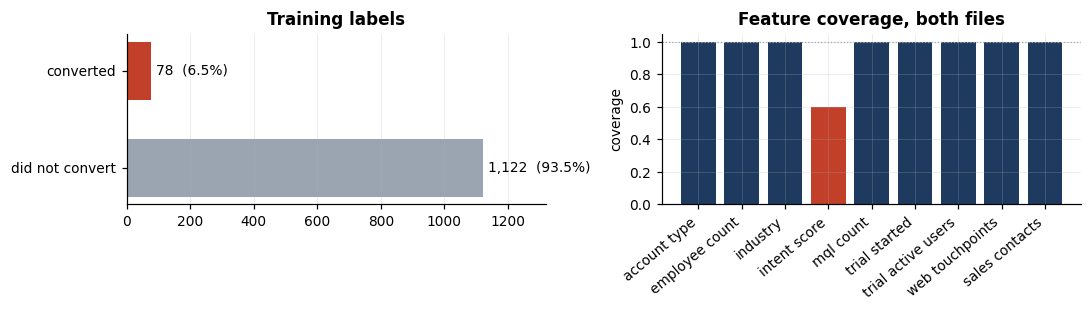

78 positives is the budget for this entire audit. Every subgroup claim below is a
partition of 78 events across 9 features. A cell with 10 accounts in it
carries roughly 0.7 expected conversions, so it can say almost nothing.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 2.9))
ax[0].barh(["did not convert", "converted"], [(y==0).sum(), y.sum()], color=[MUTE, WARN], height=.6)
for i, v in enumerate([(y==0).sum(), y.sum()]):
    ax[0].text(v + 14, i, f"{v:,}  ({v/len(y):.1%})", va="center", fontsize=9)
ax[0].set_xlim(0, 1320); ax[0].set_title("Training labels"); ax[0].grid(axis="y", visible=False)

ax[1].bar(range(len(FEATURES)), [1 - both[f].isna().mean() for f in FEATURES],
          color=[WARN if f == "intent_score" else INK for f in FEATURES])
ax[1].set_xticks(range(len(FEATURES)))
ax[1].set_xticklabels([f.replace("_90d","").replace("_"," ") for f in FEATURES], rotation=40, ha="right")
ax[1].set_ylim(0, 1.05); ax[1].set_ylabel("coverage"); ax[1].set_title("Feature coverage, both files")
ax[1].axhline(1, color=MUTE, lw=.8, ls=":")
plt.tight_layout(); plt.show()

print(f"78 positives is the budget for this entire audit. Every subgroup claim below is a")
print(f"partition of {y.sum()} events across {len(FEATURES)} features. A cell with 10 accounts in it")
print(f"carries roughly {10*BASE:.1f} expected conversions, so it can say almost nothing.")

> **The governing constraint: there are 78 positives.** Not 78%, seventy-eight events.
> Every rate in this notebook is a slice of those 78. Section 6 keeps a column for `n`
> for exactly this reason, and several findings that look striking dissolve once you
> read it.

### 0.4 Provenance — what was this model actually fit on?

The packet says **don't retrain the model**, and I don't. But an audit that cannot produce
a held-out number cannot say whether the model works, and this pickle arrives with no
training script, no metrics file, and no record of a holdout.

So, the test: take an *unfitted clone* of the identical architecture, fit it to all 1200
labeled rows **in file order**, and compare its predictions to the pickle's.

In [6]:
p_pickle = model.predict_proba(X)[:, 1]

clone_inorder = clone(model).fit(X, y)
d_inorder = np.abs(clone_inorder.predict_proba(X)[:, 1] - p_pickle).max()

# same rows, same labels, different row order -> subsample=0.7 draws a different bag
perm = np.random.default_rng(0).permutation(len(y))
clone_shuf = clone(model).fit(X.iloc[perm], y[perm])
d_shuf = np.abs(clone_shuf.predict_proba(X)[:, 1] - p_pickle).max()

# and a clone fit on a 80% subset, i.e. what it would look like if a holdout HAD been used
tr_idx, _ = next(StratifiedKFold(5, shuffle=True, random_state=0).split(X, y))
d_hold = np.abs(clone(model).fit(X.iloc[tr_idx], y[tr_idx]).predict_proba(X)[:, 1] - p_pickle).max()

show(pd.DataFrame([
    ["clone fit on all 1200 rows, FILE ORDER", d_inorder, "identical" if d_inorder == 0 else "differs"],
    ["clone fit on all 1200 rows, shuffled order", d_shuf, "differs"],
    ["clone fit on an 80% subset (as if held out)", d_hold, "differs"],
], columns=["what was fit", "max |Δp| vs the pickle", ""]), "Can the pickle be reproduced?")

print(f"\nclf.init_ class_prior_ = {model.named_steps['clf'].init_.class_prior_}")
print(f"  -> {model.named_steps['clf'].init_.class_prior_[1]*len(y):.0f} positives out of {len(y)}, "
      f"which is the full labeled file, not a subset")


Can the pickle be reproduced?
-----------------------------
                                  what was fit  max |Δp| vs the pickle           
0       clone fit on all 1200 rows, FILE ORDER                  0.0000  identical
1   clone fit on all 1200 rows, shuffled order                  0.0764    differs
2  clone fit on an 80% subset (as if held out)                  0.1722    differs

clf.init_ class_prior_ = [0.935 0.065]
  -> 78 positives out of 1200, which is the full labeled file, not a subset


**The clone reproduces the pickle bit-for-bit — max |Δp| = 0.0 across all 1200 rows.**

Shuffling the row order breaks it (because `subsample=0.7` draws its bag in row order), and
fitting on any subset breaks it. Only *all 1200 rows, in this exact order* reproduces it.
The fitted `init_` prior agrees: 0.065 × 1200 = 78, the whole file.

**Two consequences, and the second is the one the panel will challenge.**

1. **The model was fit on 100% of the labeled data with no holdout.** This is no longer an
   inference from missing documentation; it is a reproduction. So every metric computed by
   scoring this pickle against `training_data.csv` — which is the only labeled data that
   exists — is an in-sample metric by construction.

2. **Cloning the architecture for diagnostics is not retraining the shipped model.** The
   pickle is never refit, never overwritten, never replaced; it remains the object under
   audit. What the clones measure is a property of *the architecture and the data* — how
   much of its apparent skill survives on rows it has not seen. That is calibrating an
   instrument against a reference, not swapping the instrument. Without it the honest
   answer to "does this work?" is "unknowable", which is not an audit.

Every clone below is `clone(model)` — the same class, the same hyperparameters, never a
model of my choosing.

---
## 1. What is in the box

In [7]:
print(model, "\n")
pre, clf = model.named_steps["pre"], model.named_steps["clf"]

hp = {k: v for k, v in clf.get_params().items()
      if k in ["n_estimators","max_depth","learning_rate","min_samples_leaf","subsample",
               "random_state","loss","max_features","min_samples_split","n_iter_no_change"]}
print("GradientBoostingClassifier:", ", ".join(f"{k}={v}" for k, v in sorted(hp.items())))

leaves = [t[0].get_n_leaves() for t in clf.estimators_]
depths = {t[0].get_depth() for t in clf.estimators_}
print(f"\n{len(clf.estimators_)} trees, depth(s) {depths}, leaves per tree: "
      f"{ {l: leaves.count(l) for l in sorted(set(leaves))} }")
print(f"transformed feature space: {pre.n_features_in_} raw -> {clf.n_features_in_} columns")

imp = pre.named_transformers_["num"]
show(pd.Series(imp.statistics_, index=NUM, name="learned median").to_frame(),
     "SimpleImputer(strategy='median') — the values it fills gaps with")

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['account_type', 'industry']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['employee_count',
                                                   'intent_score',
                                                   'mql_count_90d',
                                                   'trial_started',
                                                   'trial_active_users',
                                                   'web_touchpoints_90d',
                                                   'sales_contacts_90d'])])),
                ('clf',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=2,
         

A deliberately small, heavily regularised model: **40 trees of depth 2** — at most four
leaves each — with `learning_rate=0.05` and `subsample=0.7`. Nothing about the
configuration is reckless. Whatever goes wrong in §2 is not caused by an obviously
overpowered model, which is part of why it is easy to miss.

The imputer matters more than it looks. Only `intent_score` has gaps, and they are filled
with **25.3**. §3.4 shows that this one choice is the only reason the column contributes
anything at all.

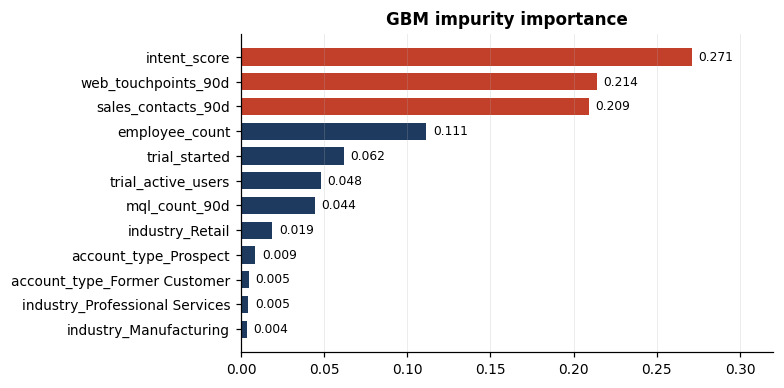

account_type one-hot columns sum to 0.0134 — the model effectively ignores the Prospect/Suspect/Former distinction
zero-importance columns: ['account_type_Suspect', 'industry_Financial Services', 'industry_Healthcare', 'industry_Software']


In [8]:
ohe   = pre.named_transformers_["cat"]
names = list(ohe.get_feature_names_out(CAT)) + NUM
gbm   = pd.Series(clf.feature_importances_, index=names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.2, 3.6))
top = gbm.head(12)[::-1]
ax.barh(top.index, top.values, color=[WARN if v > .2 else INK for v in top.values], height=.7)
for i, v in enumerate(top.values):
    ax.text(v + .004, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, .32); ax.set_title("GBM impurity importance"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(f"account_type one-hot columns sum to {gbm[[n for n in names if n.startswith('account_type')]].sum():.4f}"
      f" — the model effectively ignores the Prospect/Suspect/Former distinction")
print(f"zero-importance columns: {list(gbm[gbm == 0].index)}")

In [9]:
pr_tr, pr_sc = p_pickle, model.predict_proba(Xs)[:, 1]
show(pd.DataFrame({"training (1200)": pd.Series(pr_tr).describe(),
                   "scoring (300)":  pd.Series(pr_sc).describe()}).T[["min","25%","50%","75%","max"]],
     "predict_proba — the full output range of this model")
print(f"\nThe model never says anything strong: its most confident account in the scoring batch "
      f"is {pr_sc.max():.1%}.\nSum of predicted probabilities over the 300 = {pr_sc.sum():.2f} "
      f"expected conversions ({pr_sc.mean():.2%} average).")


predict_proba — the full output range of this model
---------------------------------------------------
                   min    25%    50%    75%    max
training (1200) 0.0359 0.0436 0.0525 0.0792 0.2698
scoring (300)   0.0381 0.0440 0.0540 0.0780 0.2094

The model never says anything strong: its most confident account in the scoring batch is 20.9%.
Sum of predicted probabilities over the 300 = 19.66 expected conversions (6.55% average).


The output lives in a narrow band — roughly 3.6% to 27% on training, and only up to
**20.9%** on the 300 accounts to be scored. This model never makes a confident claim about
any account, which is worth remembering when §2 asks whether its ordering means anything.

The last line is a number that survives everything else in this notebook: summed over the
300 accounts, the model expects **19.7 conversions, 6.55%**. The packet states the field
runs **under 1% cold and low single digits with recent engagement**. Even taken
charitably, the model's own arithmetic promises **2–6× the conversions the business
actually sees.** That gap is independent of every performance question below.

---
## 2. Reported vs. real performance

This is the section the audit turns on.

The natural thing to do with a found model is score it against the labeled data and read
off AUC. Section 0.4 showed why that number cannot mean what it appears to mean: the
pickle was fit on every one of those rows. So this section computes the in-sample metrics
anyway — because they are what anyone who looked at this model before would have seen —
and then asks the two questions that decide whether they are worth anything.

### 2.1 What the in-sample numbers say

In [10]:
def metrics(y_true, p):
    const = np.full_like(p, y_true.mean(), dtype=float)
    return {"AUC": roc_auc_score(y_true, p),
            "AP": average_precision_score(y_true, p),
            "Brier": brier_score_loss(y_true, p),
            "Brier (always predict base rate)": brier_score_loss(y_true, const),
            "log-loss": log_loss(y_true, p),
            "log-loss (base rate)": log_loss(y_true, const),
            "mean prediction": p.mean(), "observed rate": y_true.mean()}

IN = metrics(y, p_pickle)
show(pd.Series(IN, name="in-sample, scored on its own training data").to_frame(), "In-sample")
print(f"\nAP lift over prevalence: {IN['AP']/BASE:.2f}x")


In-sample
---------
                                  in-sample, scored on its own training data
AUC                                                                   0.7590
AP                                                                    0.2309
Brier                                                                 0.0573
Brier (always predict base rate)                                      0.0608
log-loss                                                              0.2185
log-loss (base rate)                                                  0.2405
mean prediction                                                       0.0661
observed rate                                                         0.0650

AP lift over prevalence: 3.55x


In [11]:
def lift_table(scores, y_true, ks=(30, 60, 120, 240)):
    order = np.argsort(-scores, kind="stable")
    br = y_true.mean()
    return pd.DataFrame([{"K": k, "positives": int(y_true[order[:k]].sum()),
                          "precision": y_true[order[:k]].mean(),
                          "lift": y_true[order[:k]].mean() / br,
                          "expected at random": k * br} for k in ks]).set_index("K")

show(lift_table(p_pickle, y), "Cumulative lift, in-sample")

dec = pd.DataFrame({"p": p_pickle, "y": y})
dec["decile"] = pd.qcut(dec.p, 10, labels=False)
cal = dec.groupby("decile").agg(n=("y","size"), predicted=("p","mean"), observed=("y","mean"))
show(cal, "Calibration by decile, in-sample")


Cumulative lift, in-sample
--------------------------
     positives  precision   lift  expected at random
K                                                   
30          12     0.4000 6.1538              1.9500
60          15     0.2500 3.8462              3.9000
120         32     0.2667 4.1026              7.8000
240         42     0.1750 2.6923             15.6000

Calibration by decile, in-sample
--------------------------------
          n  predicted  observed
decile                          
0       120     0.0403    0.0167
1       120     0.0420    0.0250
2       120     0.0436    0.0167
3       120     0.0462    0.0167
4       120     0.0496    0.0667
5       121     0.0564    0.0083
6       119     0.0666    0.0588
7       120     0.0798    0.0917
8       120     0.0984    0.0833
9       120     0.1386    0.2667


Read cold, this looks like a usable model: **AUC 0.759**, average precision 3.5× the base
rate, the top 30 accounts converting at **40%** against a 6.5% base — a **6.2× lift** — and
a Brier score slightly better than predicting the base rate for everyone.

The calibration table already shows one flaw: the model is badly under-confident at both
ends (bottom deciles predict ~4% and observe ~2%; the top decile predicts 13.9% and
observes 26.7%). That is the finding a normal audit stops at: *"it ranks well but its
probabilities are not trustworthy."*

**That conclusion is wrong, and the next two cells are why.**

### 2.2 The null model — what does this architecture score on labels that mean nothing?

If a metric is meaningful, a model trained on **randomised labels** should not be able to
reach it. So: shuffle the target, fit an identical clone, score it in-sample exactly the
way §2.1 did, and repeat. This costs nothing and almost nobody runs it.

In [12]:
def null_distribution(n_iter=200, seed=7):
    rng, aucs, tops = np.random.default_rng(seed), [], []
    for _ in range(n_iter):
        yp = rng.permutation(y)
        p  = clone(model).fit(X, yp).predict_proba(X)[:, 1]
        aucs.append(roc_auc_score(yp, p))
        tops.append(yp[np.argsort(-p, kind="stable")[:30]].sum())
    return np.array(aucs), np.array(tops)

null_auc, null_top30 = null_distribution()
obs_auc   = IN["AUC"]
obs_top30 = int(y[np.argsort(-p_pickle, kind="stable")[:30]].sum())

show(pd.DataFrame({
    "in-sample AUC": [f"{obs_auc:.4f}", f"{null_auc.mean():.4f}", f"{np.median(null_auc):.4f}",
                      f"{null_auc.std():.4f}", f"{np.quantile(null_auc,.95):.4f}", f"{null_auc.max():.4f}"],
    "positives in top 30": [f"{obs_top30}", f"{null_top30.mean():.1f}", f"{np.median(null_top30):.0f}",
                            f"{null_top30.std():.2f}", f"{np.quantile(null_top30,.95):.0f}", f"{null_top30.max():.0f}"],
}, index=["OBSERVED (real labels)", "null mean", "null median", "null sd", "null p95", "null max"]),
     "Same architecture, 200 fits on randomly permuted labels, scored in-sample")

print(f"\nempirical p(null >= observed):  AUC {np.mean(null_auc >= obs_auc):.3f}   "
      f"top-30 {np.mean(null_top30 >= obs_top30):.3f}")


Same architecture, 200 fits on randomly permuted labels, scored in-sample
-------------------------------------------------------------------------
                       in-sample AUC positives in top 30
OBSERVED (real labels)        0.7590                  12
null mean                     0.7619                10.4
null median                   0.7619                  10
null sd                       0.0201                2.11
null p95                      0.7923                  14
null max                      0.8244                  17

empirical p(null >= observed):  AUC 0.575   top-30 0.310


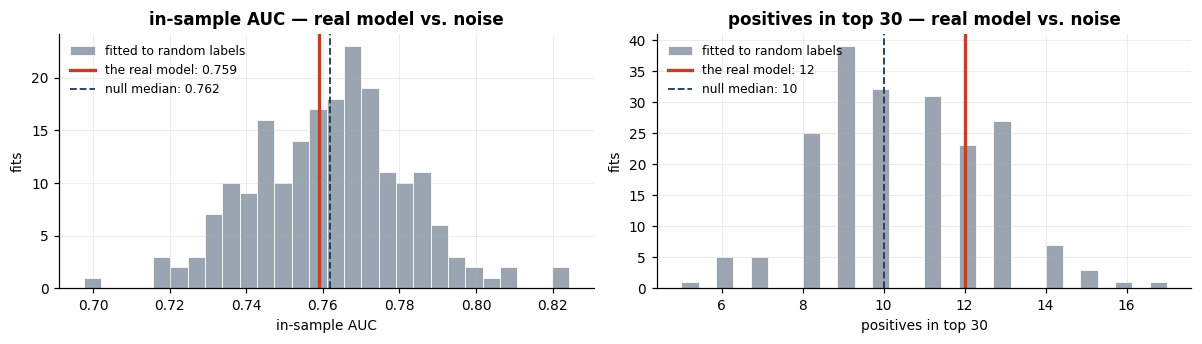

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for a, (dist, obs, lab, fmt) in zip(ax, [
        (null_auc, obs_auc, "in-sample AUC", "{:.3f}"),
        (null_top30, obs_top30, "positives in top 30", "{:.0f}")]):
    a.hist(dist, bins=28, color=MUTE, edgecolor="white", linewidth=.5,
           label="fitted to random labels")
    a.axvline(obs, color=WARN, lw=2.2, label=f"the real model: {fmt.format(obs)}")
    a.axvline(np.median(dist), color=INK, lw=1.2, ls="--", label=f"null median: {fmt.format(np.median(dist))}")
    a.set_xlabel(lab); a.set_ylabel("fits"); a.legend(fontsize=8, loc="upper left")
    a.set_title(f"{lab} — real model vs. noise")
plt.tight_layout(); plt.show()

> ### The finding
>
> **Fit this architecture to coin flips and it scores an in-sample AUC of 0.762 on average.
> The real model scores 0.759 — p = 0.57. It is below the median of the noise
> distribution.**
>
> The same holds for the headline lift: random labels put **10.4 positives** in the top 30
> on average; the real model puts 12 (p = 0.31). Across 200 fits, roughly a third of the
> noise runs beat the real model outright, and the best of them reached 17.

Both tables in §2.1 are arithmetically correct and evidentially empty. 40 depth-2 trees
have enough capacity to carve 1200 rows into groups that separate any 78 of them, and
scoring that carving on the same 1200 rows measures the carving, not the signal.

This is also, almost certainly, **the mechanism behind the folklore in the brief** — the
earlier effort that "looked promising in testing" and then "stopped matching what reps were
seeing in the field." An in-sample AUC of 0.76 is exactly what *promising in testing* looks
like. What reps saw in the field is the next cell.

### 2.3 What the model actually does on accounts it has not seen

`clone(model)` — identical architecture — refit inside each cross-validation fold, scored
only on the held-out fold. Repeated 10 times with different splits. The shipped pickle is
untouched.

In [14]:
# Refit a clone inside each fold, score only the held-out rows. Returns one out-of-fold
# prediction vector PER REPEAT -- never averaged across repeats, because averaging 10
# models' predictions is an ensemble and would flatter the result.
def out_of_fold(Xv, n_rep=10, n_split=5):
    preds = []
    for rep in range(n_rep):
        oof = np.zeros(len(y))
        for tr, te in StratifiedKFold(n_split, shuffle=True, random_state=rep).split(Xv, y):
            oof[te] = clone(model).fit(Xv.iloc[tr], y[tr]).predict_proba(Xv.iloc[te])[:, 1]
        preds.append(oof)
    return np.array(preds)

oof_all  = out_of_fold(X)
oof_p    = oof_all[0]                                  # one honest pass, used for plots
oof_aucs = np.array([roc_auc_score(y, p) for p in oof_all])
OOF      = {k: np.mean([metrics(y, p)[k] for p in oof_all]) for k in IN}

comp = pd.DataFrame({"in-sample (what §2.1 reported)": IN, "out-of-fold (honest)": OOF})
comp.loc["AUC, spread over 10 repeats"] = ["—", f"±{oof_aucs.std():.4f}"]
show(comp, "In-sample vs. out-of-fold (each repeat scored separately, then averaged)")

n1, n0 = y.sum(), (y==0).sum(); a = OOF["AUC"]
q1, q2 = a/(2-a), 2*a**2/(1+a)
se = np.sqrt((a*(1-a) + (n1-1)*(q1-a**2) + (n0-1)*(q2-a**2)) / (n1*n0))
print(f"\nout-of-fold AUC per repeat: {np.round(oof_aucs,3)}")
print(f"Hanley-McNeil 95% CI: [{a-1.96*se:.3f}, {a+1.96*se:.3f}]")
print(f"\nFor contrast -- averaging the 10 prediction vectors first and scoring once gives "
      f"AUC {roc_auc_score(y, oof_all.mean(0)):.4f}.\nThat is a 10-model ensemble, not this model. "
      f"The honest single-model figure is {a:.3f}.")


In-sample vs. out-of-fold (each repeat scored separately, then averaged)
------------------------------------------------------------------------
                                 in-sample (what §2.1 reported) out-of-fold (honest)
AUC                                                      0.7590               0.5731
AP                                                       0.2309               0.0803
Brier                                                    0.0573               0.0612
Brier (always predict base rate)                         0.0608               0.0608
log-loss                                                 0.2185               0.2416
log-loss (base rate)                                     0.2405               0.2405
mean prediction                                          0.0661               0.0652
observed rate                                            0.0650               0.0650
AUC, spread over 10 repeats                                   —              ±0.0243

ou

### 2.4 The comparison that decides whether to ship

A ranking model earns its place by beating the alternatives, and the alternative here is
not "no model" — it's sorting the list by a column, which any ops person can do in
Salesforce without involving us.

In [15]:
tiny = train.sales_contacts_90d.to_numpy() + 1e-9 * np.arange(len(y))  # deterministic tie-break
web  = train.web_touchpoints_90d.to_numpy() + 1e-9 * np.arange(len(y))
KS   = (30, 60, 120, 240)

def caught(scores, k):
    return int(y[np.argsort(-scores, kind="stable")[:k]].sum())

rng  = np.random.default_rng(0)
rand = np.mean([[y[rng.permutation(len(y))[:k]].sum() for k in KS] for _ in range(400)], axis=0)

rows = [{"ranking rule": "model, in-sample (the reported number)",
         **{f"top {k}": f"{caught(p_pickle,k)} ({caught(p_pickle,k)/(k*BASE):.2f}x)" for k in KS}}]
# the out-of-fold row is the MEAN over the 10 repeats, so it is not one lucky split
oof_caught = np.array([[caught(p, k) for k in KS] for p in oof_all], dtype=float)
rows.append({"ranking rule": "model, out-of-fold (mean of 10 repeats)",
             **{f"top {k}": f"{m:.1f} ± {s_:.1f} ({m/(k*BASE):.2f}x)"
                for k, m, s_ in zip(KS, oof_caught.mean(0), oof_caught.std(0))}})
for lab, sc in [("ORDER BY sales_contacts_90d DESC", tiny), ("ORDER BY web_touchpoints_90d DESC", web)]:
    rows.append({"ranking rule": lab, **{f"top {k}": f"{caught(sc,k)} ({caught(sc,k)/(k*BASE):.2f}x)" for k in KS}})
rows.append({"ranking rule": "random", **{f"top {k}": f"{r:.1f} (1.00x)" for k, r in zip(KS, rand)}})
show(pd.DataFrame(rows).set_index("ranking rule"), "Positives captured at each call-list depth")


Positives captured at each call-list depth
------------------------------------------
                                                    top 30             top 60            top 120             top 240
ranking rule                                                                                                        
model, in-sample (the reported number)          12 (6.15x)         15 (3.85x)         32 (4.10x)          42 (2.69x)
model, out-of-fold (mean of 10 repeats)  1.3 ± 1.2 (0.67x)  3.5 ± 1.5 (0.90x)  8.6 ± 1.7 (1.10x)  19.7 ± 4.3 (1.26x)
ORDER BY sales_contacts_90d DESC                 4 (2.05x)         10 (2.56x)         15 (1.92x)          24 (1.54x)
ORDER BY web_touchpoints_90d DESC                2 (1.03x)          8 (2.05x)         15 (1.92x)          21 (1.35x)
random                                         2.0 (1.00x)        3.9 (1.00x)        7.8 (1.00x)        15.4 (1.00x)


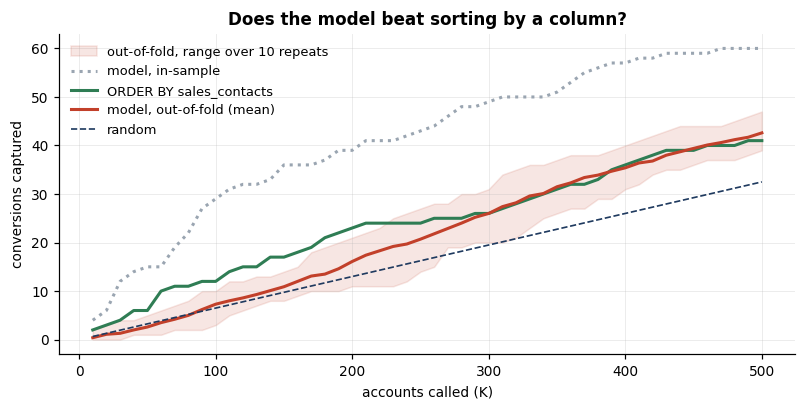

In [16]:
ks = np.arange(10, 501, 10)
fig, ax = plt.subplots(figsize=(7.4, 3.8))
curves = np.array([[y[np.argsort(-p, kind="stable")[:k]].sum() for k in ks] for p in oof_all])
ax.fill_between(ks, curves.min(0), curves.max(0), color=WARN, alpha=.13,
                label="out-of-fold, range over 10 repeats")
for lab, sc, c, ls in [("model, in-sample", p_pickle, MUTE, ":"),
                       ("ORDER BY sales_contacts", tiny, GOOD, "-")]:
    o = np.argsort(-sc, kind="stable")
    ax.plot(ks, [y[o[:k]].sum() for k in ks], color=c, ls=ls, lw=2, label=lab)
ax.plot(ks, curves.mean(0), color=WARN, lw=2, label="model, out-of-fold (mean)")
ax.plot(ks, ks * BASE, color=INK, lw=1.1, ls="--", label="random")
ax.set_xlabel("accounts called (K)"); ax.set_ylabel("conversions captured")
ax.set_title("Does the model beat sorting by a column?"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

> **`ORDER BY sales_contacts_90d DESC` — zero parameters, one line of SQL — beats the model
> out-of-fold at every call-list depth.** Averaged over ten splits, the model's honest
> top-30 finds **1.3** conversions where random finds **2.0**.

The dotted line is the number that would have gone on the slide. The solid red line is what
a rep would actually have experienced. The distance between them is the whole exercise.

### 2.5 Calibration, honestly

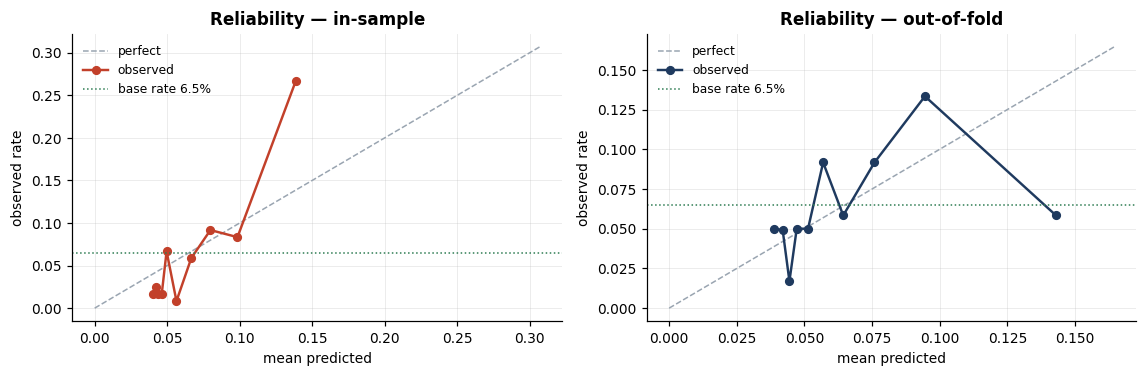

Brier, out-of-fold:              0.06123
Brier, constant 6.5% everywhere: 0.06078   <- better


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
for a, (p, lab) in zip(ax, [(p_pickle, "in-sample"), (oof_p, "out-of-fold")]):
    d = pd.DataFrame({"p": p, "y": y}); d["b"] = pd.qcut(d.p, 10, labels=False, duplicates="drop")
    g = d.groupby("b").agg(pred=("p","mean"), obs=("y","mean"), n=("y","size"))
    lo, hi = 0, max(g.pred.max(), g.obs.max()) * 1.15
    a.plot([lo, hi], [lo, hi], color=MUTE, ls="--", lw=1, label="perfect")
    a.plot(g.pred, g.obs, "o-", color=WARN if lab == "in-sample" else INK, lw=1.6, ms=5,
           label="observed")
    a.axhline(BASE, color=GOOD, lw=1, ls=":", label=f"base rate {BASE:.1%}")
    a.set_xlabel("mean predicted"); a.set_ylabel("observed rate"); a.set_title(f"Reliability — {lab}")
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Brier, out-of-fold:              {OOF['Brier']:.5f}")
print(f"Brier, constant {BASE:.1%} everywhere: {OOF['Brier (always predict base rate)']:.5f}   <- better")

In-sample the curve bends away from the diagonal but still climbs — the shape that invites
"it ranks fine, it just needs calibration." Out-of-fold the curve is essentially flat:
across the full range of scores the observed rate hovers near the base rate. There is
nothing to calibrate. Calibration repairs a ranking that is right but mis-scaled; it
cannot manufacture a ranking.

---

### Section 2 verdict

| question | answer |
|---|---|
| Does it rank? | Barely. AUC 0.573 [0.51, 0.64]. Beaten by `ORDER BY sales_contacts`. |
| Does it estimate probability? | No. Out-of-fold Brier and log-loss are **worse than a constant**. |
| Is the 0.759 headline salvageable? | No. It is at the median of what this architecture yields from random labels. |
| Would calibration fix it? | No. There is no usable ordering underneath to rescale. |
| **Ship the scores?** | **No.** Neither as probabilities nor as a ranking. |